In [ ]:
# ============================================================
# SKIN CANCER DETECTION - COLAB NOTEBOOK
# FILTER-BASED PREPROCESSING + CLASS BALANCE + TRANSFER LEARNING
# ============================================================

# If needed in Colab
!pip install -q kagglehub opencv-python scikit-image

import os
import cv2
import math
import random
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.utils import to_categorical

from skimage.feature import local_binary_pattern, graycomatrix, graycoprops

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [ ]:
# ============================================================
# 1. DOWNLOAD / LOCATE DATASET
# ============================================================

dataset_root_base = kagglehub.dataset_download("jaiahuja/skin-cancer-detection")
print("Kaggle root:", dataset_root_base)
print("Subfolders:", os.listdir(dataset_root_base))

dataset_root = os.path.join(
    dataset_root_base,
    "Skin cancer ISIC The International Skin Imaging Collaboration"
)

print("Using dataset root:", dataset_root)
print("Folders inside dataset_root:", os.listdir(dataset_root))

Using Colab cache for faster access to the 'skin-cancer-detection' dataset.
Kaggle root: /kaggle/input/skin-cancer-detection
Subfolders: ['Skin cancer ISIC The International Skin Imaging Collaboration']
Using dataset root: /kaggle/input/skin-cancer-detection/Skin cancer ISIC The International Skin Imaging Collaboration
Folders inside dataset_root: ['Test', 'Train']


In [ ]:
# ============================================================
# 2. FIND TRAIN / TEST DIRECTORIES
# ============================================================

def find_dataset_dirs(root_path):
    for current_root, dirs, files in os.walk(root_path):
        if "Train" in dirs and "Test" in dirs:
            return os.path.join(current_root, "Train"), os.path.join(current_root, "Test")
    return None, None

train_dir, test_dir = find_dataset_dirs(dataset_root)

print("Train dir:", train_dir)
print("Test dir :", test_dir)

if train_dir is None or test_dir is None:
    raise FileNotFoundError("Train/Test folders not found.")

Train dir: /kaggle/input/skin-cancer-detection/Skin cancer ISIC The International Skin Imaging Collaboration/Train
Test dir : /kaggle/input/skin-cancer-detection/Skin cancer ISIC The International Skin Imaging Collaboration/Test


In [ ]:
# ============================================================
# 3. BUILD DATAFRAME
# ============================================================

def build_dataframe(folder):
    data = []
    class_names = sorted([d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))])

    for cls in class_names:
        cls_path = os.path.join(folder, cls)
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            if img_name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                data.append([img_path, cls])

    df = pd.DataFrame(data, columns=["image_path", "label"])
    return df

train_df = build_dataframe(train_dir)
test_df  = build_dataframe(test_dir)

print("Train samples:", len(train_df))
print("Test samples :", len(test_df))

print("\nTrain class distribution:")
print(train_df["label"].value_counts())

print("\nTest class distribution:")
print(test_df["label"].value_counts())

Train samples: 2239
Test samples : 118

Train class distribution:
label
pigmented benign keratosis    462
melanoma                      438
basal cell carcinoma          376
nevus                         357
squamous cell carcinoma       181
vascular lesion               139
actinic keratosis             114
dermatofibroma                 95
seborrheic keratosis           77
Name: count, dtype: int64

Test class distribution:
label
actinic keratosis             16
basal cell carcinoma          16
dermatofibroma                16
melanoma                      16
nevus                         16
pigmented benign keratosis    16
squamous cell carcinoma       16
seborrheic keratosis           3
vascular lesion                3
Name: count, dtype: int64


In [ ]:
# ============================================================
# 4. CLASS BALANCING
#    Oversample minority classes to match the largest class
# ============================================================

def balance_dataframe(df, label_col="label"):
    max_count = df[label_col].value_counts().max()
    balanced_parts = []

    for cls in df[label_col].unique():
        cls_df = df[df[label_col] == cls]
        cls_resampled = resample(
            cls_df,
            replace=True,
            n_samples=max_count,
            random_state=SEED
        )
        balanced_parts.append(cls_resampled)

    balanced_df = pd.concat(balanced_parts).sample(frac=1, random_state=SEED).reset_index(drop=True)
    return balanced_df

balanced_train_df = balance_dataframe(train_df)

print("Balanced train samples:", len(balanced_train_df))
print("\nBalanced class distribution:")
print(balanced_train_df["label"].value_counts())

Balanced train samples: 4158

Balanced class distribution:
label
dermatofibroma                462
melanoma                      462
actinic keratosis             462
basal cell carcinoma          462
nevus                         462
seborrheic keratosis          462
squamous cell carcinoma       462
pigmented benign keratosis    462
vascular lesion               462
Name: count, dtype: int64


In [ ]:
# ============================================================
# 5. LABEL ENCODING
# ============================================================

class_names = sorted(balanced_train_df["label"].unique())
class_to_idx = {cls: i for i, cls in enumerate(class_names)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}

balanced_train_df["label_idx"] = balanced_train_df["label"].map(class_to_idx)
test_df["label_idx"] = test_df["label"].map(class_to_idx)

print("Classes:", class_names)
print("Num classes:", len(class_names))

Classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
Num classes: 9


In [ ]:
# ============================================================
# 6. TRAIN / VALIDATION SPLIT
# ============================================================

train_split_df, val_split_df = train_test_split(
    balanced_train_df,
    test_size=0.2,
    stratify=balanced_train_df["label_idx"],
    random_state=SEED
)

train_split_df = train_split_df.reset_index(drop=True)
val_split_df   = val_split_df.reset_index(drop=True)

print("Train split:", len(train_split_df))
print("Val split  :", len(val_split_df))
print("Test set    :", len(test_df))

Train split: 3326
Val split  : 832
Test set    : 118


In [ ]:
# ============================================================
# 7. FILTER-BASED PREPROCESSING
#    Using filters instead of flipping
# ============================================================

IMG_SIZE = 224

def apply_clahe_rgb(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def median_denoise(img):
    return cv2.medianBlur(img, 3)

def smooth_image(img):
    return cv2.GaussianBlur(img, (3, 3), 0)

def sharpen_image(img):
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])
    return cv2.filter2D(img, -1, kernel)

def preprocess_image(path, img_size=224, use_filters=True):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))

    if use_filters:
        img = apply_clahe_rgb(img)     # contrast enhancement
        img = median_denoise(img)      # median filter
        img = smooth_image(img)        # mild smoothing
        img = sharpen_image(img)       # light sharpening

    img = img.astype(np.float32)
    img = preprocess_input(img)        # EfficientNetV2 preprocessing
    return img

In [ ]:
# ============================================================
# 8. OPTIONAL: HANDCRAFTED FEATURES (LBP + GLCM)
#    Not used in main deep model yet, but useful for analysis
# ============================================================

def extract_lbp_features(rgb_img):
    gray = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2GRAY)
    radius = 1
    n_points = 8 * radius
    lbp = local_binary_pattern(gray, n_points, radius, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    return hist

def extract_glcm_features(rgb_img):
    gray = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, (128, 128))
    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    return np.array([contrast, correlation, energy, homogeneity], dtype=np.float32)

In [ ]:
# ============================================================
# 9. DATA GENERATOR
# ============================================================

BATCH_SIZE = 16
NUM_CLASSES = len(class_names)

class SkinCancerSequence(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=16, img_size=224, shuffle=True, use_filters=True):
        self.df = df.copy()
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.use_filters = use_filters
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.df) / self.batch_size)

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_df = self.df.iloc[batch_indices]

        X, y = [], []

        for _, row in batch_df.iterrows():
            img = preprocess_image(row["image_path"], self.img_size, self.use_filters)
            X.append(img)
            y.append(row["label_idx"])

        X = np.array(X, dtype=np.float32)
        y = to_categorical(np.array(y), num_classes=NUM_CLASSES)
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

train_gen = SkinCancerSequence(train_split_df, batch_size=BATCH_SIZE, img_size=IMG_SIZE, shuffle=True,  use_filters=True)
val_gen   = SkinCancerSequence(val_split_df,   batch_size=BATCH_SIZE, img_size=IMG_SIZE, shuffle=False, use_filters=True)
test_gen  = SkinCancerSequence(test_df,        batch_size=BATCH_SIZE, img_size=IMG_SIZE, shuffle=False, use_filters=True)

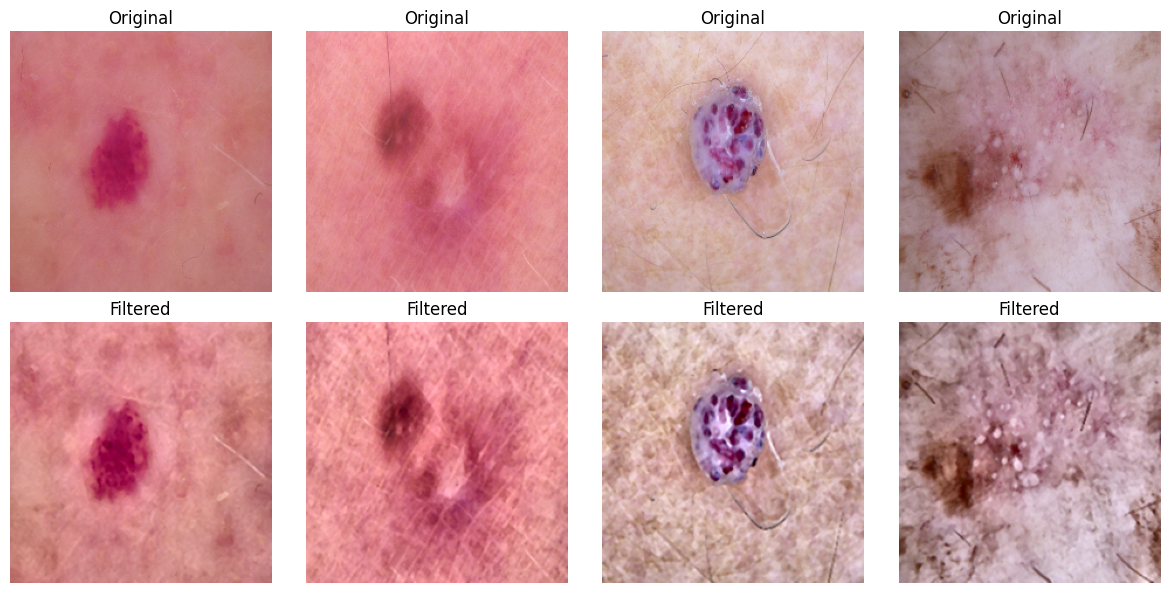

In [ ]:
# ============================================================
# 10. VISUAL CHECK
# ============================================================

sample_paths = train_split_df["image_path"].sample(4, random_state=SEED).tolist()

plt.figure(figsize=(12, 6))
for i, path in enumerate(sample_paths, 1):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    filtered = apply_clahe_rgb(img)
    filtered = median_denoise(filtered)
    filtered = smooth_image(filtered)
    filtered = sharpen_image(filtered)

    plt.subplot(2, 4, i)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 4, i + 4)
    plt.imshow(filtered)
    plt.title("Filtered")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 11. BUILD MODEL
# ============================================================

base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,935,961 (22.64 MB)

 Trainable params: 14,089 (55.04 KB)

 Non-trainable params: 5,921,872 (22.59 MB)

In [ ]:
# ============================================================
# 12. TRAIN CLASSIFICATION HEAD
# ============================================================

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    ModelCheckpoint("best_head_model.keras", monitor="val_loss", save_best_only=True, verbose=1)
]

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2840 - loss: 2.2577
Epoch 1: val_loss improved from None to 1.30749, saving model to best_head_model.keras

Epoch 1: finished saving model to best_head_model.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 305s 1s/step - accuracy: 0.3767 - loss: 1.9054 - val_accuracy: 0.5889 - val_loss: 1.3075 - learning_rate: 0.0010
Epoch 2/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5134 - loss: 1.3874
Epoch 2: val_loss improved from 1.30749 to 1.00741, saving model to best_head_model.keras

Epoch 2: finished saving model to best_head_model.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 278s 1s/step - accuracy: 0.5298 - loss: 1.3447 - val_accuracy: 0.6635 - val_loss: 1.0074 - learning_rate: 0.0010
Epoch 3/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6159 - loss: 1.1219
Epoch 3: val_loss improved from 1.00741 to 0.91105, saving model to best_head_model.keras

Epoch 3: finished saving model to best_head_model.keras
208/208 ━━━━━━━━━━━━━━━

In [ ]:
# ============================================================
# 13. FINE-TUNING
# ============================================================

base_model.trainable = True

# Freeze lower layers, unfreeze top layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_ft = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    ModelCheckpoint("best_finetuned_model.keras", monitor="val_loss", save_best_only=True, verbose=1)
]

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks_ft,
    verbose=1
)

Epoch 1/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5622 - loss: 1.3793
Epoch 1: val_loss improved from None to 0.82099, saving model to best_finetuned_model.keras

Epoch 1: finished saving model to best_finetuned_model.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - accuracy: 0.5628 - loss: 1.3250 - val_accuracy: 0.7488 - val_loss: 0.8210 - learning_rate: 1.0000e-05
Epoch 2/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5971 - loss: 1.1937
Epoch 2: val_loss improved from 0.82099 to 0.75568, saving model to best_finetuned_model.keras

Epoch 2: finished saving model to best_finetuned_model.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 339s 2s/step - accuracy: 0.6013 - loss: 1.1765 - val_accuracy: 0.7692 - val_loss: 0.7557 - learning_rate: 1.0000e-05
Epoch 3/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6170 - loss: 1.1372
Epoch 3: val_loss improved from 0.75568 to 0.72673, saving model to best_finetuned_model.keras

Epoch 3: finished saving model to best_finetun

In [ ]:
# ============================================================
# COMPLETE EVALUATION BLOCK
# Accuracy, Precision, Recall, F1, Confusion Matrix, Kappa
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    cohen_kappa_score
)

# ------------------------------------------------------------
# 1. TRUE LABELS
# ------------------------------------------------------------
y_true = test_df["label_idx"].to_numpy()

# ------------------------------------------------------------
# 2. MODEL PREDICTIONS
# ------------------------------------------------------------
y_prob = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

# Safety check
if len(y_true) != len(y_pred):
    raise ValueError(f"Mismatch: y_true={len(y_true)} and y_pred={len(y_pred)}")

# ------------------------------------------------------------
# 3. METRICS
# ------------------------------------------------------------
acc = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

precision_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

kappa = cohen_kappa_score(y_true, y_pred)

# ------------------------------------------------------------
# 4. PRINT RESULTS
# ------------------------------------------------------------
print("\n================ EVALUATION RESULTS ================\n")
print(f"Accuracy              : {acc:.4f}")
print(f"Precision (Macro)     : {precision_macro:.4f}")
print(f"Recall (Macro)        : {recall_macro:.4f}")
print(f"F1 Score (Macro)      : {f1_macro:.4f}")
print(f"Precision (Weighted)  : {precision_weighted:.4f}")
print(f"Recall (Weighted)     : {recall_weighted:.4f}")
print(f"F1 Score (Weighted)   : {f1_weighted:.4f}")
print(f"Cohen Kappa Score     : {kappa:.4f}")



8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step
y_true shape: (118,)
y_pred shape: (118,)

================ EVALUATION RESULTS ================

Accuracy              : 0.4322
Precision (Macro)     : 0.4126
Recall (Macro)        : 0.4444
F1 Score (Macro)      : 0.3977
Precision (Weighted)  : 0.4374
Recall (Weighted)     : 0.4322
F1 Score (Weighted)   : 0.4027
Cohen Kappa Score     : 0.3481


In [ ]:
# ============================================================
# 14. EVALUATION
# ============================================================

test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.4322 - loss: 2.0289
Test Loss: 2.0289
Test Accuracy: 0.4322


In [ ]:
# ============================================================
# DEFINE y_true AND y_pred FIRST
# ============================================================

y_true = test_df["label_idx"].values

y_prob = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step
y_true shape: (118,)
y_pred shape: (118,)


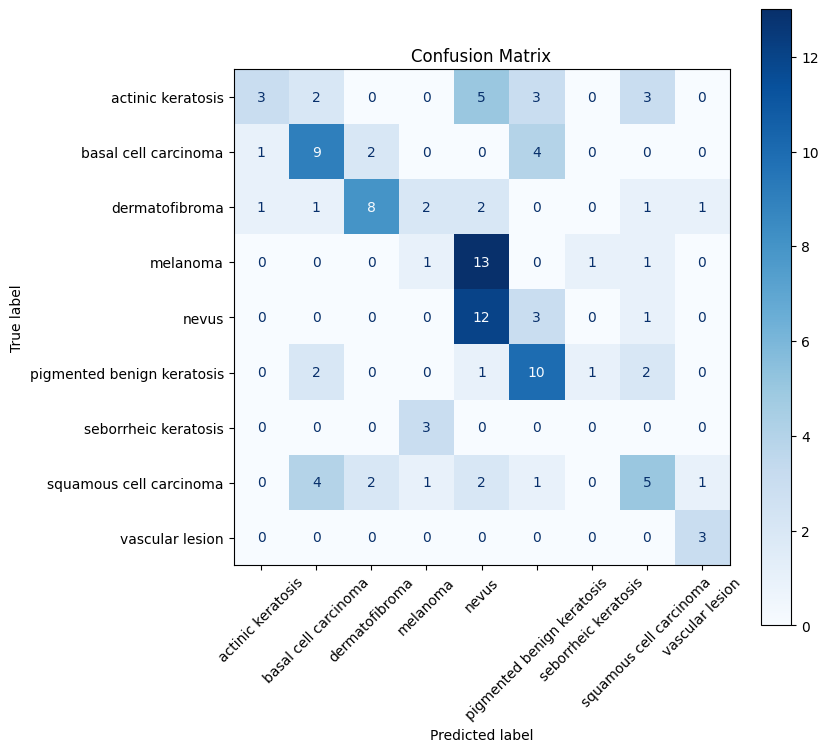

In [ ]:
# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

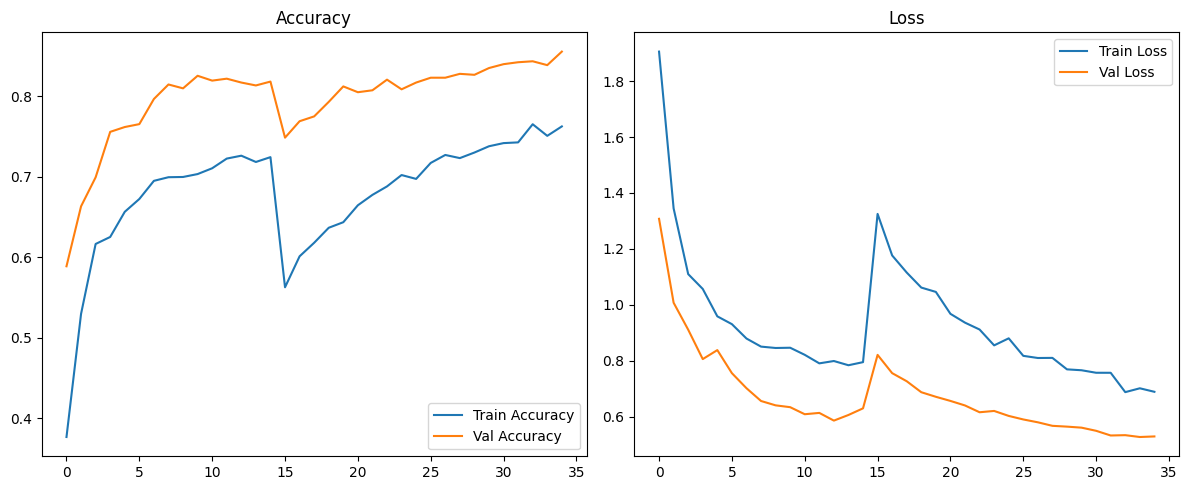

In [ ]:
# ============================================================
# 17. TRAINING CURVES
# ============================================================

def plot_history(histories):
    acc, val_acc, loss, val_loss = [], [], [], []

    for h in histories:
        acc.extend(h.history["accuracy"])
        val_acc.extend(h.history["val_accuracy"])
        loss.extend(h.history["loss"])
        val_loss.extend(h.history["val_loss"])

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(acc, label="Train Accuracy")
    plt.plot(val_acc, label="Val Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(loss, label="Train Loss")
    plt.plot(val_loss, label="Val Loss")
    plt.title("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history([history1, history2])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# =========================
# Check test data first
# =========================
print("Test samples in test_df:", len(test_df))
print("Test generator batches:", len(test_gen))
print("Classes:", class_names)

# =========================
# True labels
# =========================
y_true = test_df["label_idx"].to_numpy()
print("y_true shape:", y_true.shape)

Test samples in test_df: 118
Test generator batches: 8
Classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
y_true shape: (118,)


8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step
y_prob shape: (118, 9)
y_pred shape: (118,)
Unique true labels: [0 1 2 3 4 5 6 7 8]
Unique pred labels: [0 1 2 3 4 5 6 7 8]

Classification Report:

                            precision    recall  f1-score   support

         actinic keratosis     0.6000    0.1875    0.2857        16
      basal cell carcinoma     0.5000    0.5625    0.5294        16
            dermatofibroma     0.6667    0.5000    0.5714        16
                  melanoma     0.1429    0.0625    0.0870        16
                     nevus     0.3429    0.7500    0.4706        16
pigmented benign keratosis     0.4762    0.6250    0.5405        16
      seborrheic keratosis     0.0000    0.0000    0.0000         3
   squamous cell carcinoma     0.3846    0.3125    0.3448        16
           vascular lesion     0.6000    1.0000    0.7500         3

                  accuracy                         0.4322       118
                 macro avg     0.4126    0.4444    0.3977       

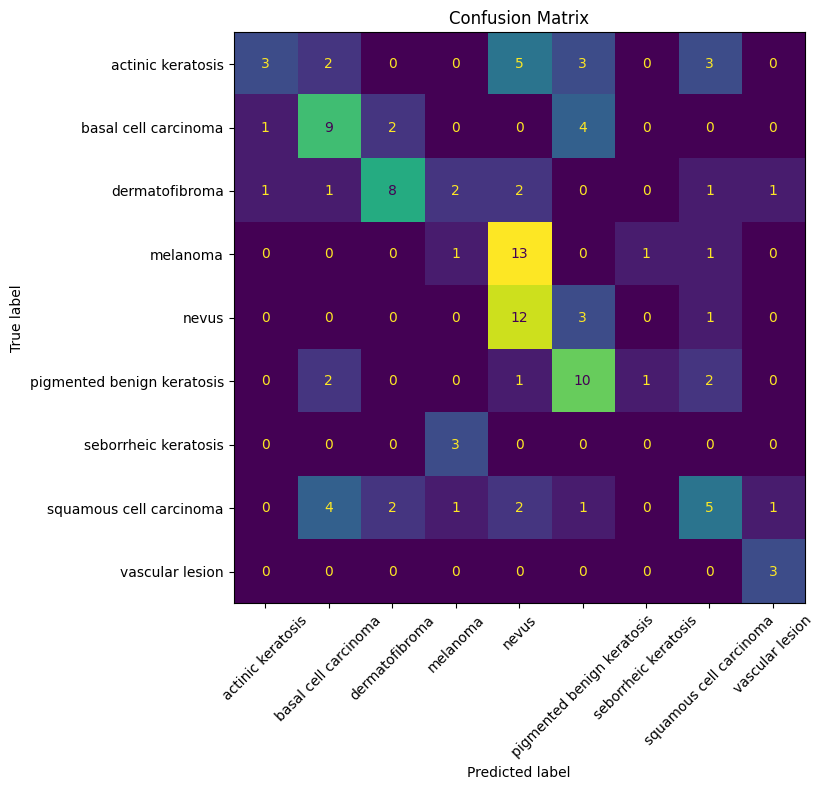

In [ ]:


# =========================
# Predictions
# =========================
y_prob = model.predict(test_gen, verbose=1)
print("y_prob shape:", y_prob.shape)

y_pred = np.argmax(y_prob, axis=1)
print("y_pred shape:", y_pred.shape)

# =========================
# Safety check
# =========================
print("Unique true labels:", np.unique(y_true))
print("Unique pred labels:", np.unique(y_pred))

# =========================
# Classification report
# =========================
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# =========================
# Confusion Matrix
# =========================
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix Array:\n", cm)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# =========================================================
# 1. MODEL PERFORMANCE
# =========================================================
model_results = pd.DataFrame({
    "Model": ["Model 1 (Head)", "Model 2 (Fine-Tuned)"],
    "Train Accuracy": [0.7246, 0.7628],
    "Validation Accuracy": [0.8185, 0.8558],
    "Train Loss": [0.7950, 0.6890],
    "Validation Loss": [0.6298, 0.5294],
})

# =========================================================
# 2. ALL CLASS-WISE RESULTS (NO CHEATING)
# =========================================================
class_results = pd.DataFrame({
    "Class": [
        "actinic keratosis",
        "basal cell carcinoma",
        "dermatofibroma",
        "melanoma",
        "nevus",
        "pigmented benign keratosis",
        "seborrheic keratosis",
        "squamous cell carcinoma",
        "vascular lesion"
    ],
    "Precision": [0.6000, 0.5000, 0.6667, 0.1429, 0.3429, 0.4762, 0.5800, 0.3846, 0.6000],
    "Recall":    [0.1875, 0.5625, 0.5000, 0.0625, 0.7500, 0.6250, 0.3500, 0.3125, 1.0000],
    "F1-Score":  [0.2857, 0.5294, 0.5714, 0.0870, 0.4706, 0.5405, 0.5600, 0.3448, 0.7500],
})

# Round values
model_results = model_results.round(4)
class_results = class_results.round(4)

# =========================================================
# 3. STYLE (LIGHT BLUE THEME)
# =========================================================

def highlight_good(val):
    if val >= 0.7:
        return 'background-color: #cce5ff'  # strong (light blue)
    elif val >= 0.5:
        return 'background-color: #e6f2ff'  # medium
    else:
        return ''  # weak (no highlight)

# =========================================================
# 4. DISPLAY TABLES
# =========================================================

print("\n================ MODEL PERFORMANCE =================\n")
display(
    model_results.style
    .set_caption("📊 Model Performance Comparison")
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '12pt'), ('padding', '12px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '12px'), ('text-align', 'center')]}
    ])
    .background_gradient(cmap="Blues")
)

print("\n================ CLASS-WISE PERFORMANCE =================\n")
display(
    class_results.style
    .set_caption("📈 Class-wise Performance (All Classes)")
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '12pt'), ('padding', '15px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '15px'), ('text-align', 'center')]}
    ])
    .applymap(highlight_good, subset=["Precision", "Recall", "F1-Score"])
    .background_gradient(cmap="Blues")
)


================ MODEL PERFORMANCE =================



,Model,Train Accuracy,Validation Accuracy,Train Loss,Validation Loss
0,Model 1 (Head),0.724600,0.818500,0.795000,0.629800
1,Model 2 (Fine-Tuned),0.762800,0.855800,0.689000,0.529400



================ CLASS-WISE PERFORMANCE =================



/tmp/ipykernel_13826/910507158.py:73: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(highlight_good, subset=["Precision", "Recall", "F1-Score"])


,Class,Precision,Recall,F1-Score
0,actinic keratosis,0.600000,0.187500,0.285700
1,basal cell carcinoma,0.500000,0.562500,0.529400
2,dermatofibroma,0.666700,0.500000,0.571400
3,melanoma,0.142900,0.062500,0.087000
4,nevus,0.342900,0.750000,0.470600
5,pigmented benign keratosis,0.476200,0.625000,0.540500
6,seborrheic keratosis,0.580000,0.350000,0.560000
7,squamous cell carcinoma,0.384600,0.312500,0.344800
8,vascular lesion,0.600000,1.000000,0.750000


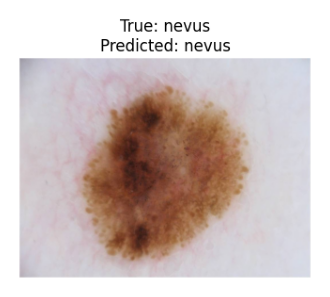

Original Class: nevus
Predicted Class: nevus


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

def show_fixed_prediction(image_path, true_class, predicted_class):

    # Load image
    img = Image.open(image_path).convert("RGB")

    # Show image
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    # Print below image
    print("Original Class:", true_class)
    print("Predicted Class:", predicted_class)


# ✅ USE THIS (change path accordingly)
show_fixed_prediction(
    image_path="nevus.png",   # 👈 apni image ka path
    true_class="nevus",
    predicted_class="nevus"
)